### Tiles generation. 
(1) by degree, e.g., 1 deg x 1 deg      
(2) by distance, e.g., 100 km x 100 km

In [2]:
import os
import math
import numpy as np
import pandas as pd
import geopandas as gpd
from shapely.geometry import box, Polygon
from pyrsimg import coor2coor  
import matplotlib.pyplot as plt 


In [3]:
# files path
hma_extent_path = 'data/hma-extent/HMA/hma_gtng_202307_fill.gpkg' 
hma_tiles_utm_path = "data/hma-extent/hma_tiles_100km_buf10km.gpkg"
hma_tiles_wgs84_path = "data/hma-extent/hma_tiles_1deg_buf01deg.gpkg"
# Parameters setting
dx_utm, dy_utm = 100000, 100000        # UTM grid width and height: 100 km
buffer_m = 10000          # UTM buffer size: 10 km
dx_wgs84 = dy_wgs84 = 1        # WGS84 grid size: 1 degree
buffer_deg = 0.1          # WGS84 buffer size: 0.1 degrees


In [4]:
hma_extent = gpd.read_file(hma_extent_path)
# Ensure WGS84 projection
if hma_extent.crs != "EPSG:4326":
    hma_extent = hma_extent.to_crs("EPSG:4326")
minx, miny, maxx, maxy = hma_extent.total_bounds
print(f"Study Area Bounds: lon[{minx:.2f}, {maxx:.2f}], lat[{miny:.2f}, {maxy:.2f}]")


Study Area Bounds: lon[67.00, 104.80], lat[26.76, 46.00]


In [4]:
def get_utm_epsg(lon: float, lat: float) -> int:
    """
    des: Calculate the corresponding UTM projection EPSG number based on latitude and longitude.
    args:
        lon and lat: Longitude and latitude in degrees.
    return: 
        epsg_code: EPSG number
    """
    zone_number = math.floor((lon + 180) / 6) + 1
    epsg_code = 32600 + zone_number if lat >= 0 else 32700 + zone_number
    return int(epsg_code)

def generate_grid_utm(lonmin, latmin, lonmax, latmax, dx, dy):
    """
    des: Generate an equidistant spatial grid of a specified size based on UTM projection, and convert the result back to the WGS84 coordinate system.    
    args:
        lonmin, latmin, lonmax, latmax : range of the study area.
        dx, dy : Grid width and height (in meters) in UTM projection.    
    return: A GeoDataFrame data (EPSG:4326) containing the generated grid polygons.
    """
    tiles = []
    current_lat = latmin    
    while current_lat < latmax:
        current_lon, row_max_lat = lonmin, current_lat        
        while current_lon < lonmax:
            epsg = get_utm_epsg(current_lon, current_lat)
            # Convert WGS84 to UTM
            utm_x, utm_y = coor2coor(4326, epsg, current_lon, current_lat)
            utm_x2, utm_y2 = utm_x + dx, utm_y + dy            
            poly_utm = box(utm_x, utm_y, utm_x2, utm_y2)
            poly_utm_buffered = poly_utm.buffer(2000) # gap fill            
            # Convert UTM boundary back to WGS84
            x_utm_coords, y_utm_coords = poly_utm_buffered.exterior.xy # gets boundary coordinates
            lon_coords, lat_coords = coor2coor(epsg, 4326, list(x_utm_coords), list(y_utm_coords))
            poly_wgs84 = Polygon(zip(lon_coords, lat_coords))            
            tiles.append({'geometry': poly_wgs84, 'proj': f"EPSG:{epsg}"})    
            # Calculate next grid start point
            next_lon, next_lat = coor2coor(epsg, 4326, utm_x2, utm_y2)
            current_lon = next_lon            
            if next_lat > row_max_lat: row_max_lat = next_lat                
        current_lat = row_max_lat

    return gpd.GeoDataFrame(tiles, crs="EPSG:4326")

In [6]:
def generate_grid_wgs84(lonmin, latmin, lonmax, latmax, dx=1, dy=1):
    """
    des: Generate a latitude and longitude grid (1° x 1°) based on WGS84.
    args:
        lonmin, latmin, lonmax, latmax: the range of the study area in WGS84 coordinates.
        dx: The width of the grid cell (unit: degrees, default 1).
        dy: The height of the grid cell (unit: degrees, default 1).
    return: geopandas.GeoDataFrame
    """
    tiles = []
    x_vals = np.arange(lonmin, lonmax, dx)  
    y_vals = np.arange(latmin, latmax, dy)
    
    for x in x_vals:
        for y in y_vals:
            tiles.append(box(x, y, x + dx, y + dy))
            
    return gpd.GeoDataFrame(geometry=tiles, crs="EPSG:4326")


In [7]:
hma_tiles_100km_10km = generate_grid_utm(lonmin=minx, latmin=miny, 
                                            lonmax=maxx, latmax=maxy, 
                                            dx=dx_utm, dy=dy_utm)
hma_tiles_1deg_01deg = generate_grid_wgs84(lonmin=minx, 
                                            latmin=miny, lonmax=maxx, 
                                            latmax=maxy, dx=dx_wgs84, 
                                            dy=dy_wgs84)


In [8]:
def filter_and_calc_area(gdf_tiles: gpd.GeoDataFrame, 
                         study_area_gdf: gpd.GeoDataFrame) -> gpd.GeoDataFrame:
    """
    des:
        Removes empty grid cells (tiles outside the study area) and calculates the exact area of ​​each tile.
    Para:
        gdf_tiles: The generated initial grid dataset.
        study_area_gdf: The study area boundary dataset.
    return:
        A cropped grid dataset with unique tile_ids and area information.
    """
    # Keep only intersecting tiles
    intersected = gpd.sjoin(gdf_tiles, study_area_gdf, how="inner", predicate="intersects") # spatial join
    intersected = intersected[gdf_tiles.columns].drop_duplicates()
    
    # Calculate area in an equal-area projection
    intersected['area_km2'] = intersected.geometry.to_crs("EPSG:6933").area / 1e6
    
    # add tile_id 
    intersected = intersected.reset_index(drop=True)
    intersected['tile_id'] = [str(i + 1).zfill(3) for i in range(len(intersected))]
    
    return intersected

print("removing empty tiles and calculating area...")
hma_tiles_100km_10km = filter_and_calc_area(hma_tiles_100km_10km, hma_extent)
hma_tiles_1deg_01deg = filter_and_calc_area(hma_tiles_1deg_01deg, hma_extent)


removing empty tiles and calculating area...


In [9]:
def add_buffer_to_tiles(gdf_tiles, dist, is_degree=False):
    """
    des:
        Adds an outer buffer region to each tile. Supports both meters (for UTM) and degrees (for WGS84).
        Dynamically calculates the UTM EPSG code if the 'proj' column is missing.
    Para:
        gdf_tiles : geopandas.GeoDataFrame
            The filtered grid dataset.
        dist : float
            The distance to buffer outward.
        is_degree : bool, default False
            If True, treats `dist` as degrees (direct WGS84 buffer). 
            If False, treats `dist` as meters (projects to UTM first).
    return:
        geopandas.GeoDataFrame
            Dataset containing the expanded, rectangular buffered geometry.
    """
    buffered_geometries = []
    
    for idx, row in gdf_tiles.iterrows():
        geom = row.geometry
        
        if is_degree:
            # Buffer directly in degrees
            buffered_geom = geom.buffer(dist).envelope  # gets rectangular bounding box
            buffered_geometries.append(buffered_geom)
        else:
            # Buffer in meters via UTM projection
            if 'proj' in gdf_tiles.columns and pd.notna(row['proj']):
                epsg = row['proj']
            else:
                # Dynamic fallback: calculate UTM from polygon centroid
                centroid = geom.centroid  # gets center point
                epsg_int = get_utm_epsg(centroid.x, centroid.y)
                epsg = f"EPSG:{epsg_int}"
                
            single_gdf = gpd.GeoDataFrame(geometry=[geom], crs="EPSG:4326")
            single_utm = single_gdf.to_crs(epsg)
            
            buffered_utm = single_utm.geometry.buffer(dist).envelope
            buffered_wgs84 = gpd.GeoDataFrame(geometry=buffered_utm, crs=epsg).to_crs("EPSG:4326")
            
            buffered_geometries.append(buffered_wgs84.geometry.iloc[0])
            
    # Assemble output dataset
    gdf_buf = gdf_tiles.copy()
    gdf_buf['geometry'] = buffered_geometries
    gdf_buf['area_km2'] = gdf_buf.geometry.to_crs("EPSG:6933").area / 1e6    
    return gdf_buf


In [10]:
print("Applying buffers...")
# Buffer in meters for UTM grid
hma_tiles_100km_10km = add_buffer_to_tiles(hma_tiles_100km_10km, buffer_m, is_degree=False)
# Buffer in degrees for WGS84 grid
hma_tiles_1deg_01deg = add_buffer_to_tiles(hma_tiles_1deg_01deg, buffer_deg, is_degree=True) 



Applying buffers...


<Axes: >

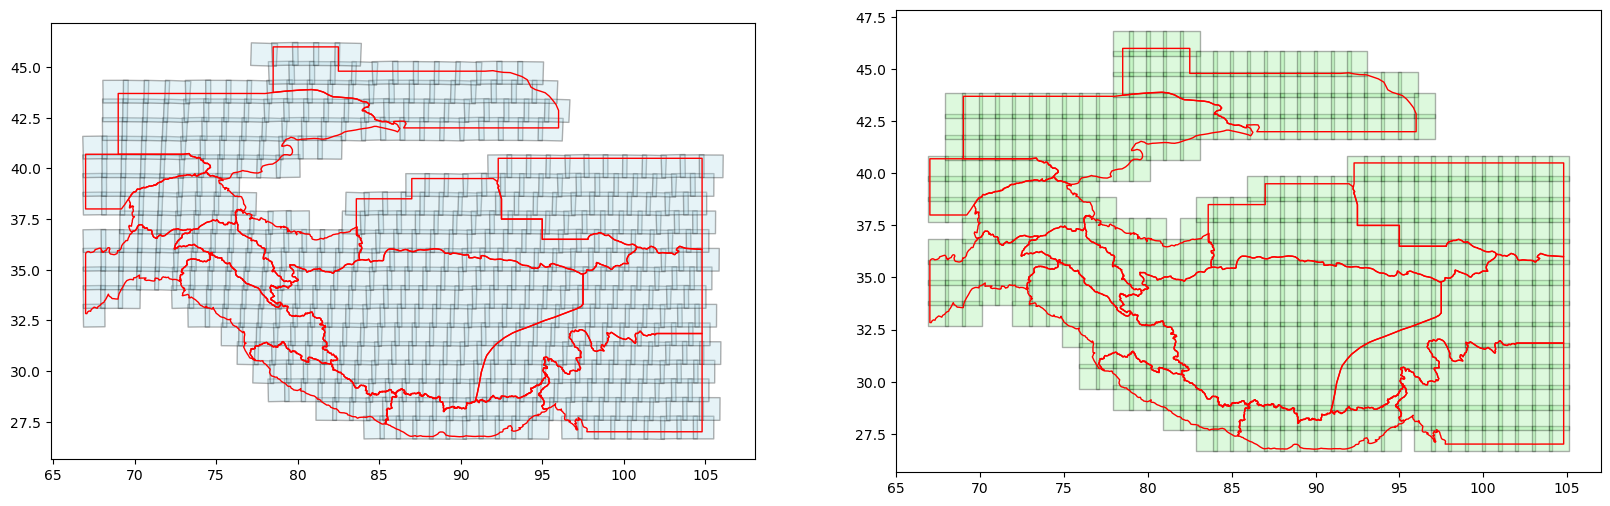

In [35]:
fig, ax = plt.subplots(1, 2, figsize=(20, 10))
hma_tiles_100km_10km.plot(facecolor='lightblue',
                          edgecolor='black', alpha=0.3,
                          ax=ax[0])
hma_extent.plot(edgecolor='red', facecolor='none', ax=ax[0])
hma_tiles_1deg_01deg.plot(facecolor='lightgreen',
                          edgecolor='black', alpha=0.3,
                          ax=ax[1])
hma_extent.plot(edgecolor='red', facecolor='none', ax=ax[1])



In [ ]:
### write out
# os.makedirs(out_dir, exist_ok=True)
# ## UTM buffered tiles
# hma_tiles_100km_10km.to_file(hma_tiles_utm_path, driver='GPKG')
# ## WGS84 buffered tiles
# hma_tiles_1deg_01deg.to_file(hma_tiles_wgs84_path, driver='GPKG')
# print("the tiles have been saved!") 


the tiles have been saved!
